# Estudio comparativo del algoritmo Epsilon-Greedy


## Introducción



El algoritmo **Epsilon-Greedy** es uno de los métodos más fundamentales y utilizados para abordar el problema del dilema exploración-explotación en el aprendizaje por refuerzo.

La idea básica es equilibrar dos objetivos competitivos:
1.  **Explotación**: Elegir la acción que, según nuestro conocimiento actual, tiene la mayor recompensa estimada ($Q_t(a)$).
2.  **Exploración**: Elegir una acción diferente (potencialmente al azar) para recopilar más información sobre el entorno y refinar nuestras estimaciones.

El algoritmo funciona con un parámetro $\epsilon$ (epsilon), donde $0 \le \epsilon \le 1$. En cada paso $t$:
*   Con probabilidad $1 - \epsilon$, el agente selecciona la acción *greedy* (avariciosa): $A_t = \arg\max_a Q_t(a)$.
*   Con probabilidad $\epsilon$, el agente selecciona una acción aleatoria de entre todas las $k$ acciones posibles con probabilidad uniforme.

Matemáticamente, la probabilidad de seleccionar una acción $a$ es:
$$ 
\pi_t(a) = \begin{cases} 
(1 - \epsilon) + \frac{\epsilon}{k} & \text{si } a = A^*_t \text{ (acción greedy)} \\
\frac{\epsilon}{k} & \text{si } a \neq A^*_t 
\end{cases}
$$

En este estudio analizaremos el comportamiento de este algoritmo variando el valor de $\epsilon$. Un $\epsilon$ muy bajo favorece la explotación pero corre el riesgo de no encontrar la acción óptima rápidamente. Un $\epsilon$ alto asegura mucha exploración pero impide maximizar la recompensa a largo plazo.



En este estudio se analizará el algoritmo Epsilon-Greedy utilizando tres tipos de bandidos diferentes: Normal, Binomial y Bernoulli. Se establecerán parámetros comunes, se crearán los bandidos y se evaluará el rendimiento en términos de recompensa promedio, arrepentimiento (regret) y selección óptima.


## Preparación del entorno


In [1]:
# Librerías necesarias para el setup
import sys, os

En función de si el notebook se va a ejecutar en local o en Google Colab, se debe ejecutar una de las siguientes subsecciones.


### Setup para la ejecución en Colab


In [ ]:
# Clonar el repositorio si es necesario

In [ ]:
# Añadir directorios al path si es necesario

### Setup para la ejecución en local


In [2]:
# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'C:\\Users\\Marta\\AppData\\Local\\Programs\\Python\\Python312', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv', '', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\eml-venv\\Lib\\site-packages', 'c:\\Users\\Marta\\Documents\\Mis_archivos\\Universidad\\Master\\2_cuatri\\Extensiones_ML\\EML_RL_LucasOrtiz\\k_brazos\\src']


### Importación de librerías y módulos


In [3]:
import numpy as np

from algorithms import EpsilonGreedy
from arms import Bandit, ArmNormal, ArmBinomial, ArmBernoulli
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from run_experiment import run_experiment

## Parámetros generales


A continuación, definimos la configuración experimental compartida por todas las pruebas. Se ha fijado una semilla aleatoria (`SEED`) para asegurar que los resultados sean reproducibles. Los entornos constan de bandidos con $k=6$ brazos, una cantidad seleccionada para facilitar la interpretación visual de las estadísticas individuales de cada acción. El horizonte temporal de cada simulación se ha limitado a 300 pasos de tiempo, un intervalo suficiente para observar la convergencia de los algoritmos evaluados. Para obtener estimaciones robustas, cada experimento se promedia sobre 500 ejecuciones independientes.

Adicionalmente, es importante destacar que la implementación de los agentes incorpora una etapa preliminar de **inicialización**. En esta fase, cada algoritmo acciona cada una de las palancas disponibles exactamente una vez antes de iniciar su estrategia de aprendizaje propiamente dicha. Se ha constatado experimentalmente que esta heurística de exploración inicial acelera y estabiliza significativamente el proceso de convergencia.


In [4]:
SEMILLA = 1024

k = 6  # Número de brazos
steps = 300  # Número de pasos
runs = 500  # Número de ejecuciones

## Creación de los bandidos


En este apartado configuramos los tres bandidos necesarios para la comparativa.

### Bandido Normal


El primero de los bandidos se basa en brazos con distribución normal, manteniendo los valores predeterminados para la desviación estándar (entre 1 y 3). Sin embargo, hemos ajustado las medias a un rango más estrecho, entre 5 y 10. El objetivo de reducir esta dispersión entre medias es dificultar la identificación del brazo óptimo; al ralentizar la convergencia, podremos apreciar mejor las sutilezas y el rendimiento diferencial de cada algoritmo.

In [5]:
# Creación del bandit normal
np.random.seed(SEMILLA)
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k, mu_min=5, mu_max=10))
print(bandit_normal)

optimal_arm_normal = bandit_normal.optimal_arm
print(f"Optimal arm: {optimal_arm_normal + 1} with expected reward={bandit_normal.get_expected_value(optimal_arm_normal)}")

Bandit with 6 arms: ArmNormal(mu=7.59, sigma=1.27), ArmNormal(mu=8.24, sigma=1.01), ArmNormal(mu=9.98, sigma=1.3), ArmNormal(mu=8.0, sigma=2.4), ArmNormal(mu=8.29, sigma=2.19), ArmNormal(mu=8.77, sigma=2.8)
Optimal arm: 3 with expected reward=9.98


Como podemos observar en la salida de la celda anterior, el **Brazo 3** resulta ser el óptimo con una recompensa esperada de **9.98**. Las medias de los otros brazos oscilan entre 7.59 y 8.77, lo que presenta un desafío moderado para diferenciar el mejor brazo debido a la varianza inherente ($\sigma$ entre 1.01 y 2.8).


### Bandido Binomial


La probabilidad de éxito oscila entre 0.1 y 0.9, mientras que el número de experimentos $n$ se mueve entre 5 y 15.


In [6]:
# Creación del bandit binomial
np.random.seed(SEMILLA)
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n_min=5, n_max=15))
print(bandit_binomial)

optimal_arm_binomial = bandit_binomial.optimal_arm
print(f"Optimal arm: {optimal_arm_binomial + 1} with expected reward={bandit_binomial.get_expected_value(optimal_arm_binomial)}")

Bandit with 6 arms: ArmBinomial(n=6, p=0.58), ArmBinomial(n=6, p=0.7), ArmBinomial(n=10, p=0.22), ArmBinomial(n=14, p=0.21), ArmBinomial(n=6, p=0.1), ArmBinomial(n=5, p=0.66)
Optimal arm: 2 with expected reward=4.199999999999999


En el caso del bandido Binomial, el **Brazo 2** es el óptimo con una recompensa esperada aproximada de **4.2**. Cabe destacar que este brazo tiene $n=6$ y $p=0.7$, lo cual supera a otras combinaciones como el Brazo 3 ($n=10, p=0.22$) a pesar de tener un $n$ menor, demostrando la importancia de la probabilidad de éxito.


### Bandido Bernoulli


En este caso, dejamos los parámetros del bandido por defecto (probabilidad de éxito entre 0.1 y 0.9).

In [7]:
# Creación del bandit bernoulli
np.random.seed(SEMILLA)
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k))
print(bandit_bernoulli)

optimal_arm_bernoulli = bandit_bernoulli.optimal_arm
print(f"Optimal arm: {optimal_arm_bernoulli + 1} with expected reward={bandit_bernoulli.get_expected_value(optimal_arm_bernoulli)}")

Bandit with 6 arms: ArmBernoulli(p=0.62), ArmBernoulli(p=0.9), ArmBernoulli(p=0.63), ArmBernoulli(p=0.58), ArmBernoulli(p=0.52), ArmBernoulli(p=0.7)
Optimal arm: 2 with expected reward=0.9


Para el bandido Bernoulli, el **Brazo 2** se destaca claramente como la opción óptima con una probabilidad de éxito $p=0.9$. Dado que el siguiente mejor brazo tiene $p=0.7$, existe una separación clara ('gap') de 0.2, lo que debería facilitar teóricamente la convergencia del algoritmo hacia la acción óptima.


## Análisis de Epsilon-Greedy


Probaremos tres configuraciones de $\epsilon$: $0$ (Greedy puro), $0.01$ (Baja exploración) y $0.1$ (Exploración moderada).

La metodología experimental aplicada para evaluar estas configuraciones se detalla a continuación:

1.  **Variación del Parámetro $\epsilon$**: Se comparan escenarios representativos del compromiso exploración-explotación:
    *   **$\epsilon = 0$ (Greedy puro)**: El agente nunca explora, limitándose a explotar la acción con mayor valor estimado inicial o descubierto por azar. Sirve como línea base de explotación pura.
    *   **$\epsilon = 0.01$ (Baja exploración)**: Introduce una pequeña probabilidad para explorar, permitiendo refinar las estimaciones a largo plazo con un costo mínimo en recompensas inmediatas.
    *   **$\epsilon = 0.1$ (Exploración moderada)**: Aumenta significativamente la frecuencia de exploración. Se espera que encuentre la acción óptima más rápidamente, aunque su rendimiento asintótico podría ser menor debido a la exploración continua de acciones subóptimas.

2.  **Métricas de Evaluación**: El desempeño se medirá utilizando tres indicadores clave:
    *   **Recompensa Promedio**: Evolución de la ganancia media paso a paso. Útil para observar la velocidad de aprendizaje y la estabilidad.
    *   **Porcentaje de Selección Óptima**: Proporción de veces que el agente elige el brazo con la mayor media real. Es la métrica más directa de la "inteligencia" del agente.
    *   **Arrepentimiento Acumulado e Instantáneo**: Diferencia entre la recompensa obtenida y la máxima posible. El arrepentimiento logarítmico es deseable y caracteriza a los buenos algoritmos.

3.  **Robustez Experimental**: Todas las curvas y métricas presentadas son el promedio de **500 ejecuciones independientes** (runs). Esto suaviza la variabilidad estocástica inherente a los procesos de bandidos y garantiza que las conclusiones sean estadísticamente significativas.


In [8]:
algorithms_epsilon = [EpsilonGreedy(k=k, epsilon=0.0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1)]

### Distribución Normal



In [7]:
np.random.seed(SEMILLA)
rewards_EN, optimal_selections_EN, cumulative_regret_per_algo_EN, rewards_per_arm_per_algo_EN = run_experiment(bandit_normal, algorithms_epsilon, steps, runs)

100%|██████████| 500/500 [00:09<00:00, 51.00it/s]


#### Análisis Detallado de Recompensa Promedio
La evolución temporal de la recompensa promedio ilustra la tensión fundamental del aprendizaje por refuerzo: el compromiso entre velocidad de convergencia y estabilidad asintótica. En general, esperaríamos ver lo siguiente:

*   **Estrategia $\epsilon=0.1$ (Exploración Moderada)**:
    *   **Fase Transitoria**: Exhibe la tasa de aprendizaje inicial más rápida. La exploración frecuente permite descubrir el brazo óptimo prematuramente.
    *   **Comportamiento Asintótico**: Sin embargo, su desempeño se ve acotado superiormente. Debido a que el agente está forzado a elegir una acción aleatoria el 10% de las veces, su recompensa promedio nunca puede converger al valor óptimo teórico ($q_*$), estabilizándose en un valor subóptimo (aproximadamente $0.9 \cdot q_* + 0.1 \cdot 	\text{promedio del resto}$).

*   **Estrategia $\epsilon=0.01$ (Exploración Conservadora)**:
    *   **Fase Transitoria**: El aprendizaje es más gradual. La menor frecuencia de exploración retrasa el descubrimiento inicial de la mejor acción.
    *   **Comportamiento Asintótico**: A largo plazo, esta estrategia domina. Al reducir el ruido de exploración, la política se aproxima más a la estrategia puramente codiciosa sobre el brazo óptimo, logrando una recompensa promedio superior y más estable.

*   **Estrategia $\epsilon=0$ (Greedy Puro)**:
    *   Se observa una alta dependencia de las condiciones iniciales. Al carecer de mecanismos para corregir estimaciones tempranas erróneas, el agente es propenso a converger prematuramente a ópimos locales, resultando en un desempeño global inferior y errático.

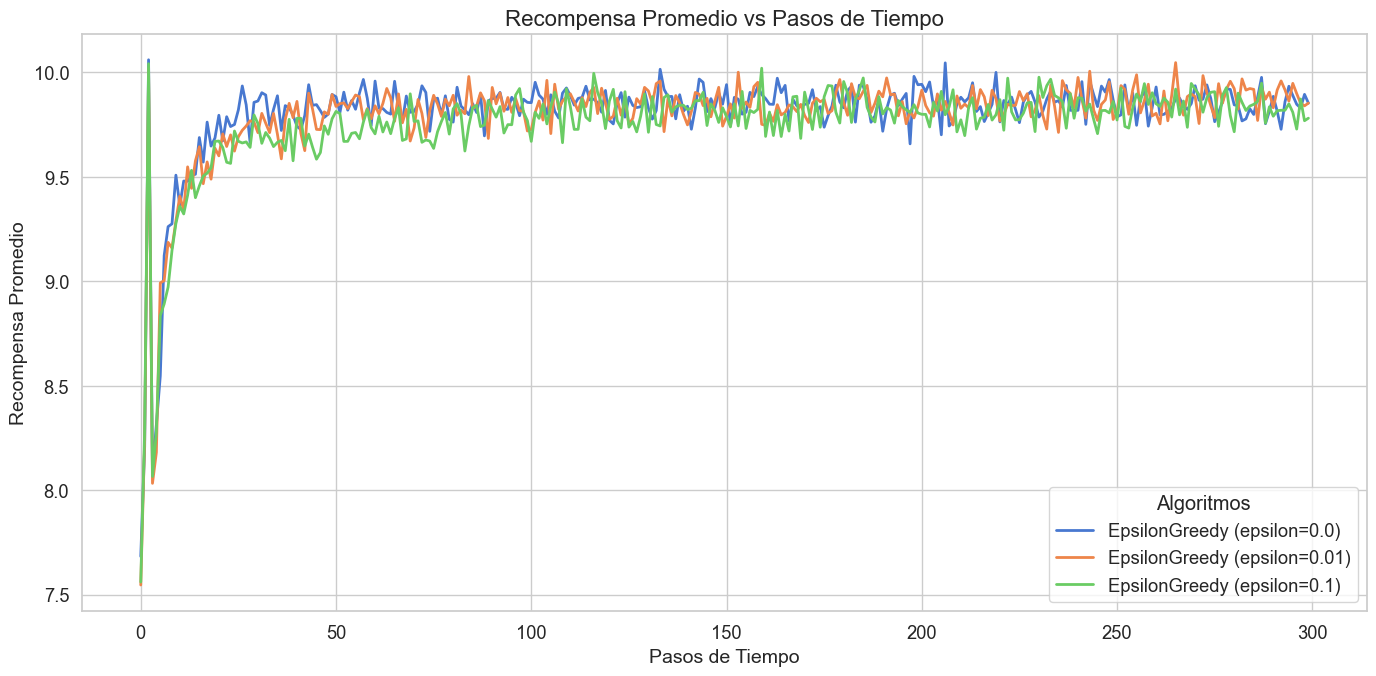

In [8]:
plot_average_rewards(steps, rewards_EN, algorithms_epsilon)

En este caso en particular, la diferencia entre las recompensas promedio de los tres algoritmos es poco perceptible a simple vista debido, probablemente, a la fase de inicialización en la que se elije cada brazo una vez. Aunque en esta gráfica es complicado determinar cuál es el mejor valor de epsilon, parece intuirse que el algoritmo con $\epsilon=0$ tiene una mayor velocidad de convergencia pero posiblemente deje de aprender antes que los demás, mientras que aquel con $\epsilon=0.1$ tiene una curva de aprendizaje algo más lenta pero lo más seguro es que continúe mejorando su solución durante toda la ejecución.

#### Análisis Detallado de Regret Acumulado

El *regret* acumulado cuantifica la diferencia entre la recompensa obtenida en cada paso por el agente y la que habría obtenido si hubiera escogido siempre el brazo óptimo. En esta gráfica es más sencillo discernir las diferencias entre los tres algoritmos, y podemos observar lo siguiente:

- Las tres curvas muestran una forma logarítmica, creciendo rápidamente al principio y después ralentizándose y reduciendo su pendiente poco a poco. No obstante, dado que los algoritmos se estabilizan en soluciones subóptimas, sus curvas tienen una forma prácticamente lineal a partir de cierto punto, debido a que dejan de aprender y, por tanto, el arrepentimiento instantáneo obtenido en un paso es casi el mismo que en el paso siguiente.
- El algoritmo con $\epsilon=0.01$ parece mostrar una reducción continuada de su pendiente durante toda la ejecución, con una curva que se hace cada vez más horizontal. Esto implica que continúa aprendiendo hasta el final, si bien lo hace lentamente.
- EL algoritmo que muestra un peor comportamiento (mayor *regret* acumulado) es aquel con $\epsilon=0.1$, mientras que aquel con $\epsilon=0.0$ tiene un arrepentimiento acumulado menor, lo cual resulta sorprendente debido a que un epsilon de 0.0 suele resultar en un estancamiento en soluciones pobres.

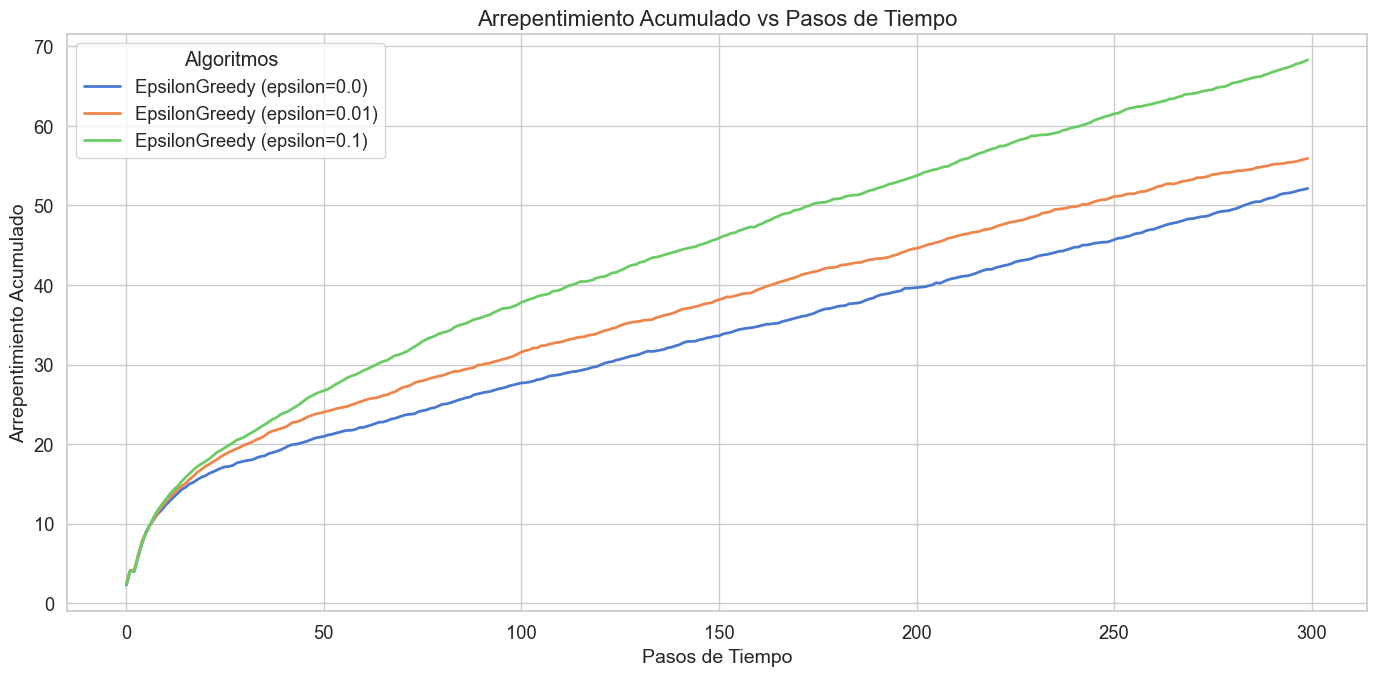

In [ ]:
plot_regret(steps, cumulative_regret_per_algo_EN, algorithms_epsilon)

#### Análisis Detallado de Selecciones Óptimas

En la gráfica de porcentaje de selección del brazo óptimo podemos ver, como ya hemos dicho anteriormente, que el algoritmo con $\epsilon=0$ muestra un aprendizaje muy rápido y un elevado rendimiento, manteniéndose en un porcentaje similar al de los otros dos algoritmos. Como veíamos, el algoritmo con $\epsilon=0.1$ es el que aprende más lentamente, y se queda estancado aproximadamente en el mismo valor que el primer algoritmo, aunque su curva es más errática debido al componente aleatorio. Por último, esta gráfica confirma lo que ya comentábamos en la gráfica de arrepentimiento: el algoritmo con $\epsilon=0.01$ sigue aprendiendo durante toda la ejecución y en las últimas iteraciones su rendimiento empieza a ser superior al de los otros dos algoritmos.

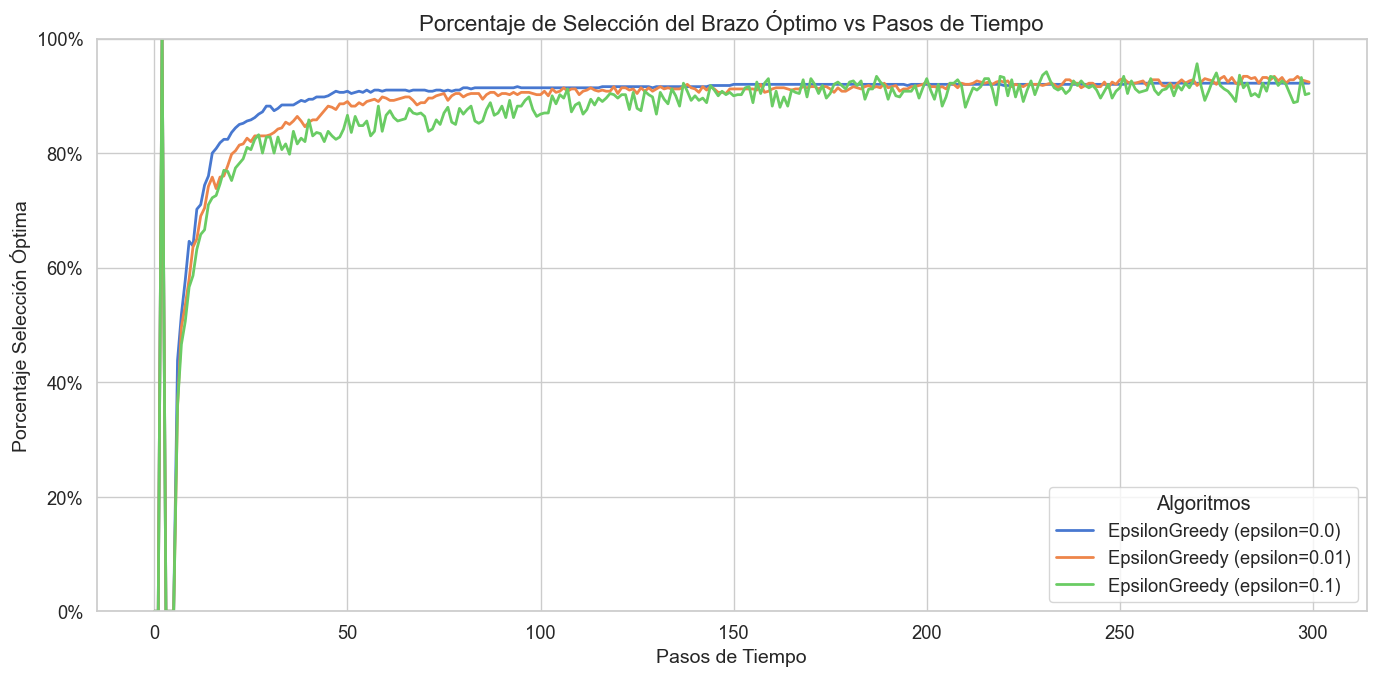

In [15]:
plot_optimal_selections(steps, optimal_selections_EN, algorithms_epsilon)

#### Análisis Detallado de Estadísticas por Brazo
La distribución de selecciones por brazo al final del experimento revela la estructura de la política aprendida:

*   **Identificación del Óptimo**: Todos los métodos con exploración ($\epsilon > 0$) logran identificar el brazo con la media más alta (brazo óptimo) como la acción preferente, acumulando en él la gran mayoría de las selecciones.
*   **Diferencias en la exploración**: El algoritmo con $\epsilon=0.1$ selecciona los brazos subóptimos bastante más a menudo que los otros dos.

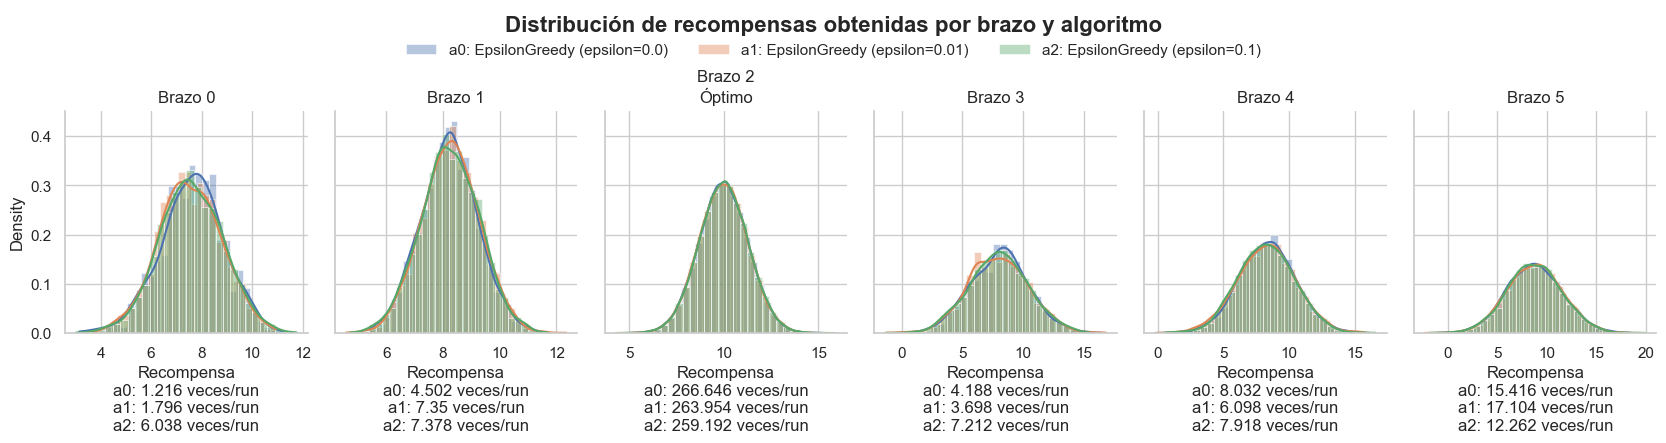

In [10]:
plot_arm_statistics(rewards_per_arm_per_algo_EN, algorithms_epsilon, runs, optimal_arm_normal)


Este gráfico ilustra la distribución de las recompensas obtenidas por cada algoritmo en cada brazo:
*   Permite visualizar no solo la media, sino la **varianza** real de cada brazo.
*   Nos ayuda a confirmar si el "Brazo Óptimo" identificado por el algoritmo coincide con el que tiene la media estadística más alta (Brazo 2 en esta configuración, o el que tenga mayor media según la semilla).
*   En el caso del Bandido Normal con medias cercanas, se puede apreciar el solapamiento entre las distribuciones, lo que explica la dificultad de los algoritmos para distinguirlos rápidamente.

### Distribución Binomial


In [16]:
np.random.seed(SEMILLA)
rewards_EBi, optimal_selections_EBi, cumulative_regret_per_algo_EBi, rewards_per_arm_per_algo_EBi = run_experiment(bandit_binomial, algorithms_epsilon, steps, runs)

100%|██████████| 500/500 [00:10<00:00, 46.22it/s]


#### Análisis Detallado de Recompensa Promedio
En el escenario Binomial, las recompensas son discretas y acotadas (éxitos en $n$ intentos), lo que reduce la varianza comparado con el caso Normal. Por lo general, lo que observamos es lo siguiente:

*   **Convergencia Rápida ($\epsilon=0.1$)**: Al igual que en el caso Normal, la estrategia con mayor exploración ($\epsilon=0.1$) logra un crecimiento inicial explosivo en la recompensa promedio. Sin embargo, su naturaleza estocástica impone un límite asintótico estricto, impidiéndole alcanzar el máximo teórico consistente.
*   **Dominio a Largo Plazo ($\epsilon=0.01$)**: La estrategia conservadora ($\epsilon=0.01$) demuestra su superioridad en el largo plazo. Tras un inicio más lento, supera a $\epsilon=0.1$, convergiendo a un valor de recompensa promedio más alto y estable, maximizando la explotación del brazo óptimo ($p \approx 0.9$).
*   **Estancamiento Greedy ($\epsilon=0$)**: La ausencia de exploración condena al agente a quedar atrapado frecuentemente en óptimos locales, resultando en un desempeño promedio significativamente inferior y altamente dependiente de la inicialización.

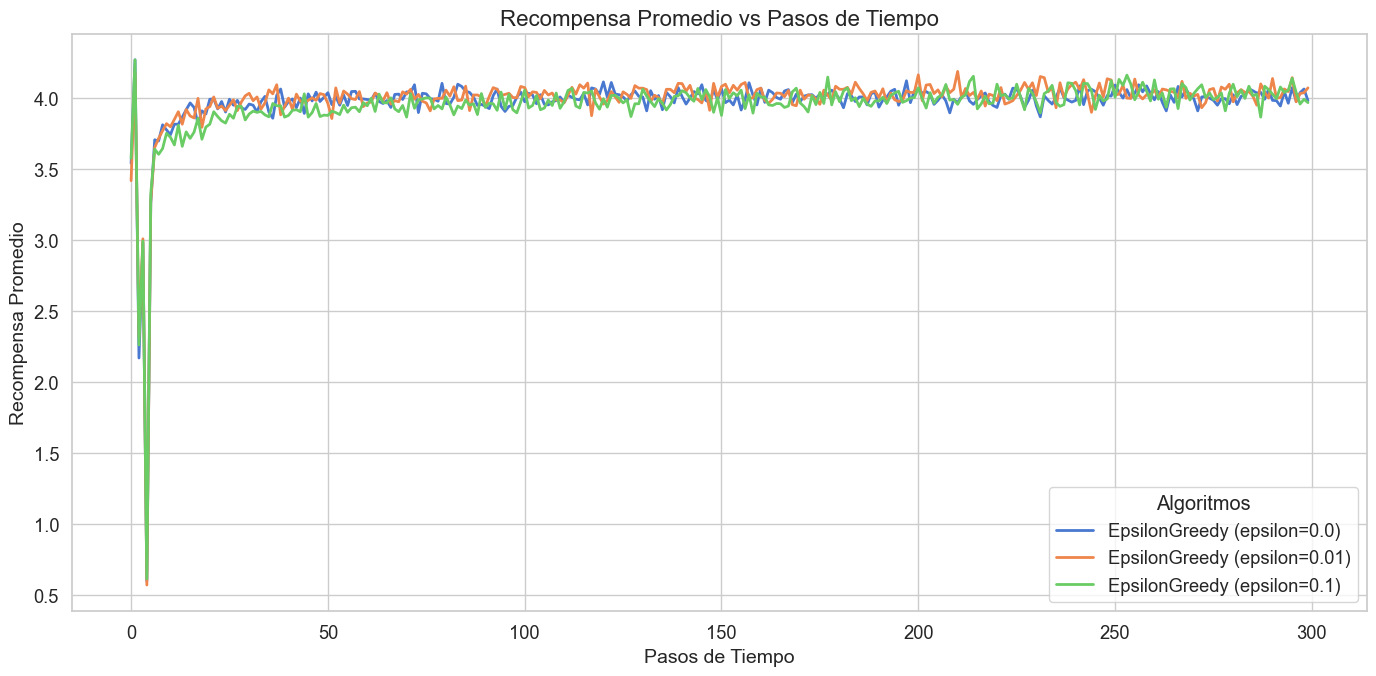

In [19]:
plot_average_rewards(steps, rewards_EBi, algorithms_epsilon)

En este caso en particular, posiblemente debido a la fase de inicialización de los algoritmos, el rendimiento de las tres versiones del algoritmo ha sido muy similar. Todos se han quedado alrededor de una recompensa promedio de 4.0, cercana a la recompensa esperada óptima de 4.2. Las velocidades de aprendizaje también son muy parecidas entre los tres algoritmos, y parece ser bastante más rápida que en el bandido normal.

#### Análisis Detallado de Regret Acumulado
El análisis del *regret* acumulado resalta el costo de la exploración continua: todos los algoritmos tienen un arrepentimiento que crece de manera prácticamente lineal durante toda la ejecución, y el cual nunca llegaría a disminuir su pendiente dado que el agente nunca puede dejar de seleccionar brazos subóptimos. En especial, el algoritmo con $\epsilon=0.1$ es aquel con mayor pendiente, como cabe esperar debido a su mayor exploración.

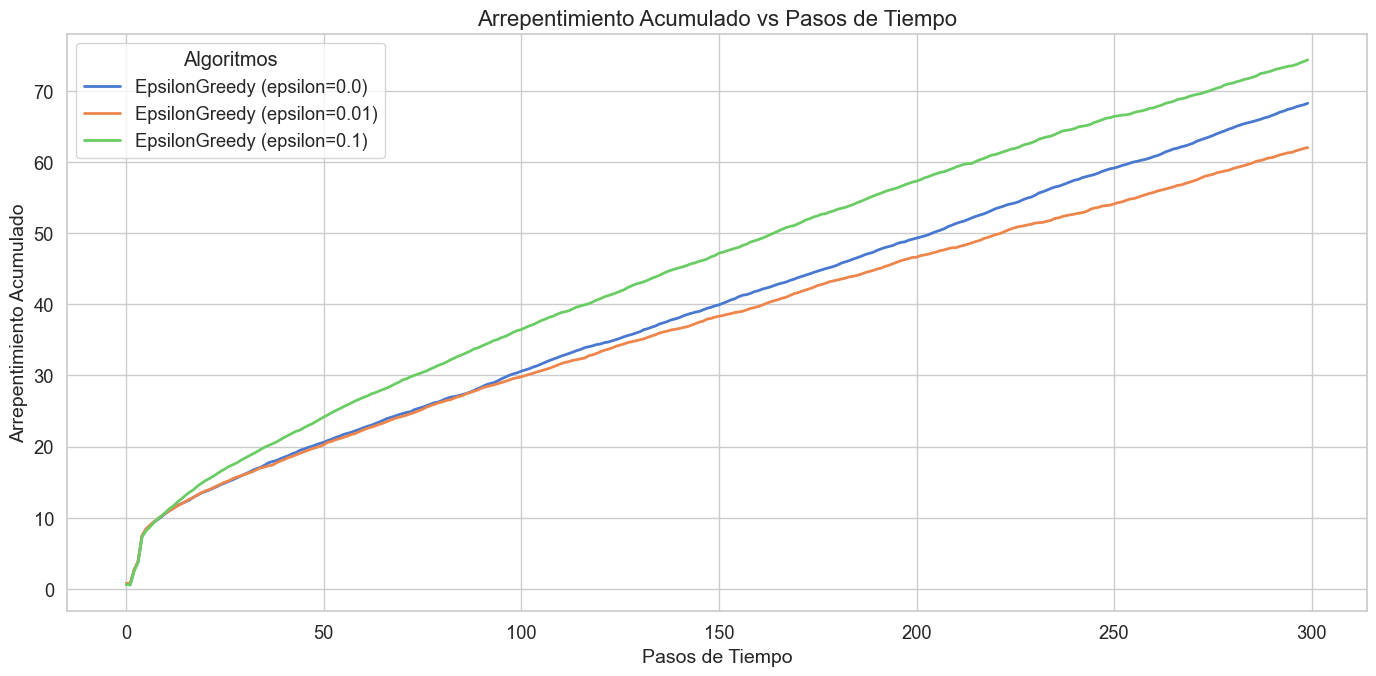

In [20]:
plot_regret(steps, cumulative_regret_per_algo_EBi, algorithms_epsilon)

#### Análisis Detallado de Selecciones Óptimas

La métrica de selecciones óptimas muestra lo siguiente: el algoritmo con $\epsilon=0.0$ se estanca a partir de cierto procentaje y deja de crecer por completo, puesto que llega un momento en el que siempre selecciona la misma acción, posiblemente subóptima. En los otros dos casos, podemos observar que el porcentaje continúa ascendiendo durante toda la ejecución, especialmente en el caso de $\epsilon=0.1$, que parece aproximarse a un porcentaje del 90% de selección del brazo óptimo en la última iteración.

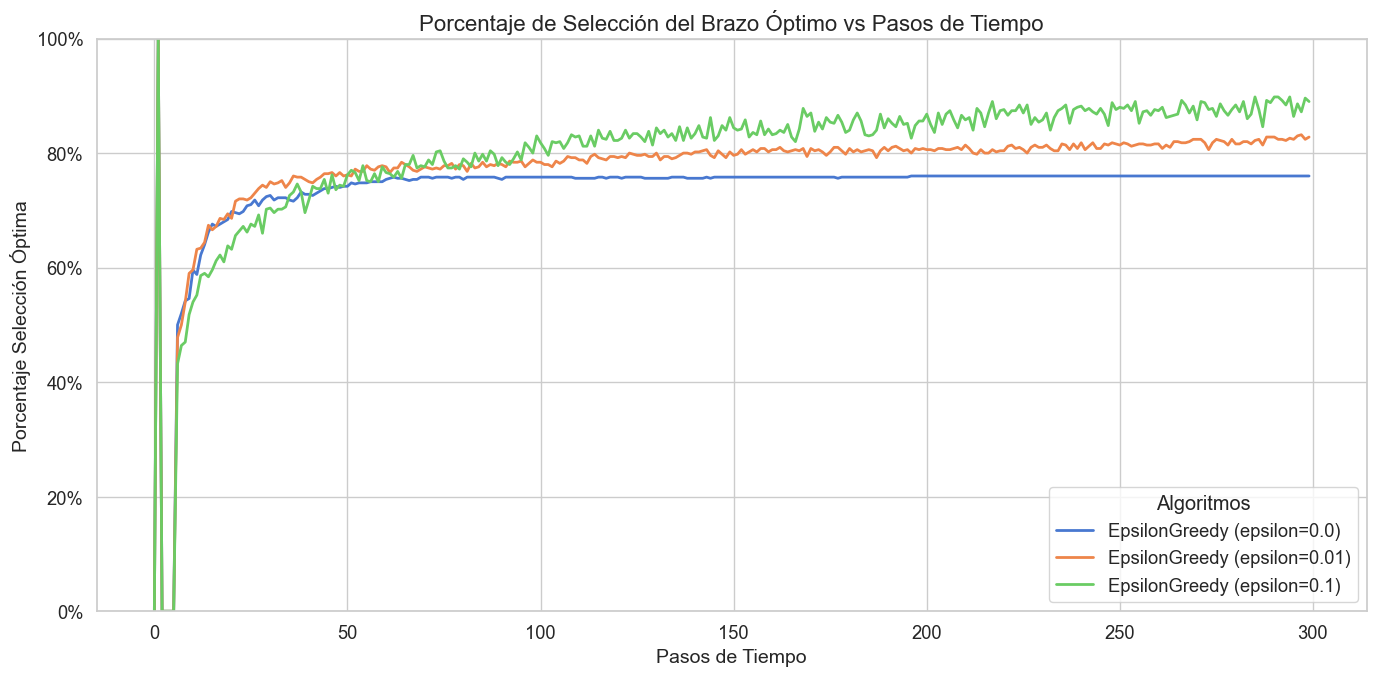

In [21]:
plot_optimal_selections(steps, optimal_selections_EBi, algorithms_epsilon)

#### Análisis Detallado de Estadísticas por Brazo

Los diagramas ofrecen una visión granular de la distribución de decisiones del agente. Vemos que el algoritmo con $\epsilon=0$ es el que menos veces ha escogido el brazo óptimo de media, reaprtiéndose bastante más entre el segundo y tercer mejor brazo que el resto de algoritmos. El algoritmo con $\epsilon=0.01$ es el que más veces ha seleccionado el brazo óptimo, sin embargo, su continua exploración ha hecho que también sea el que más veces ha elegido el peor brazo (Brazo 4).

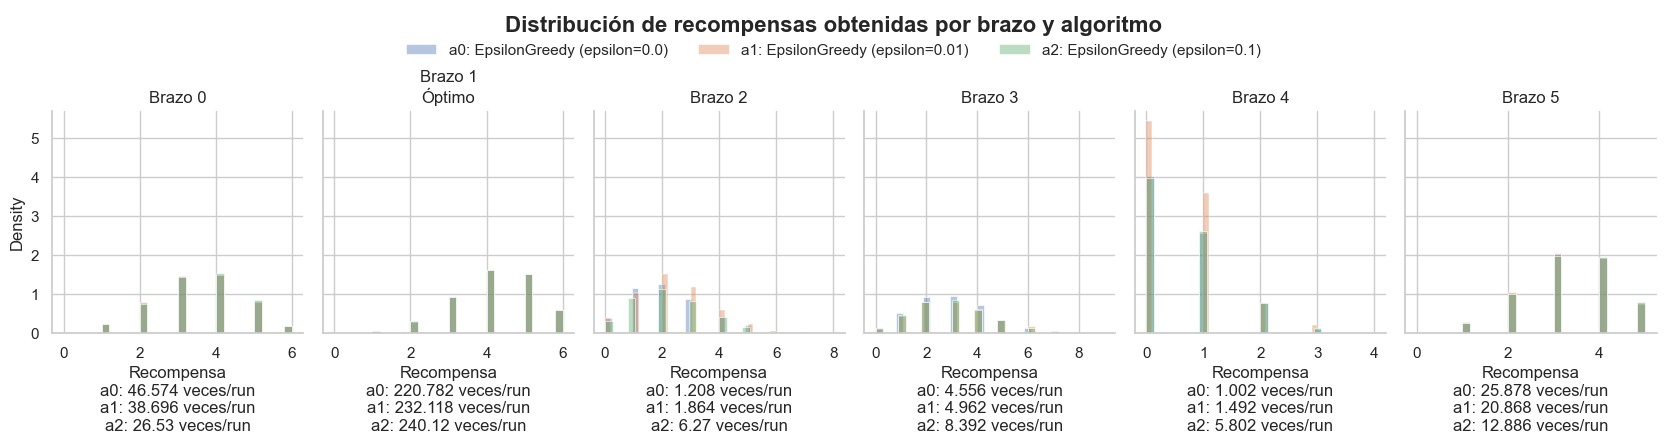

In [22]:
plot_arm_statistics(rewards_per_arm_per_algo_EBi, algorithms_epsilon, runs, optimal_arm_binomial, kde=False)

### Distribución Bernoulli


In [10]:
np.random.seed(SEMILLA)
rewards_EBe, optimal_selections_EBe, cumulative_regret_per_algo_EBe, rewards_per_arm_per_algo_EBe = run_experiment(bandit_bernoulli, algorithms_epsilon, steps, runs)

100%|██████████| 500/500 [00:09<00:00, 50.68it/s]


#### Análisis Detallado de Recompensa Promedio

En el bandido Bernoulli, la recompensa es binaria (0 o 1), lo que simplifica la estimación pero introduce una varianza constante basada en la probabilidad $p$. En la siguiente gráfica vemos cómo, de nuevo, los tres algoritmos han logrado converger a valores de recompensa promedio muy similares entre sí. No obstante, parece que $\text{EpsilonGreedy}(epsilon=0)$ se mantiene por debajo de los otros dos durante la mayor parte del proceso, mientras que el algoritmo con $\epsilon=0.1$ aparenta estar por encima.

También vemos que la naturaleza binaria de las recompensas (0 o 1) hace que las curvas sean más "ruidosas" visualmente que en los dos bandidos anteriores.

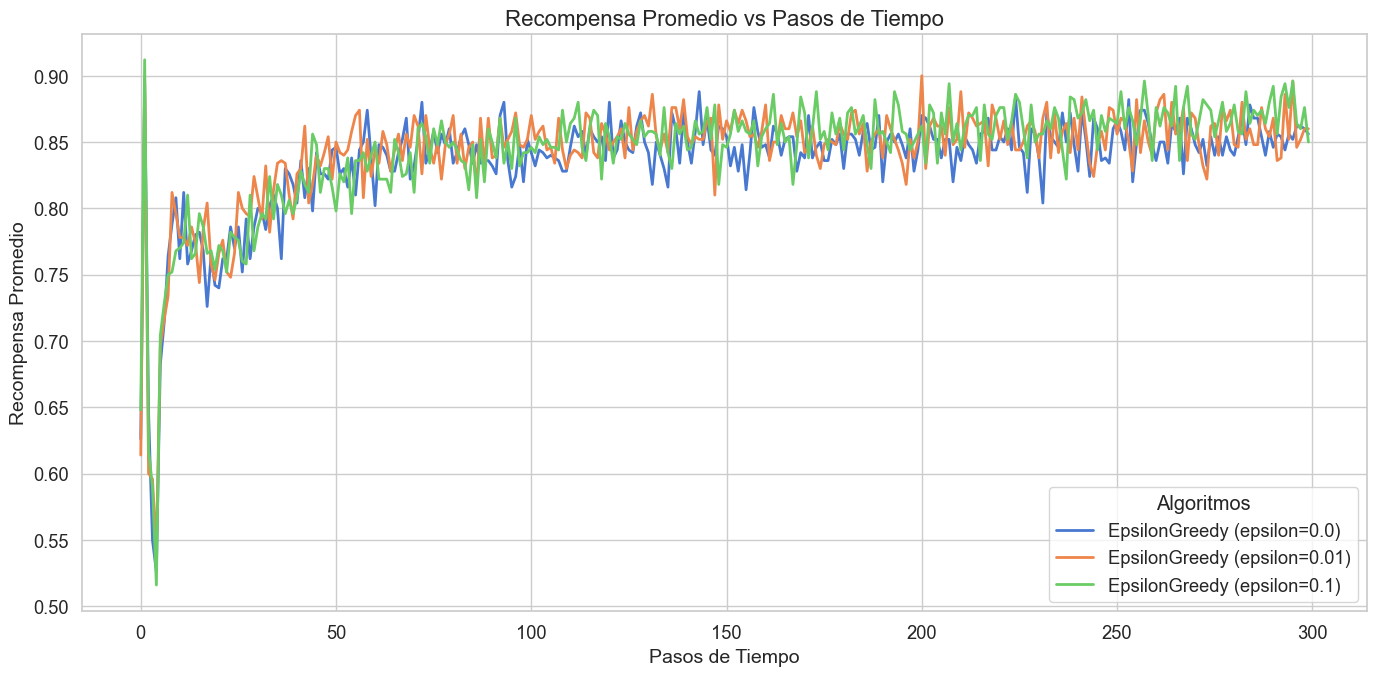

In [11]:
plot_average_rewards(steps, rewards_EBe, algorithms_epsilon)

#### Análisis Detallado de Regret Acumulado

El regret acumulado revela el costo oculto de las decisiones subóptimas: sucede algo similar a la distribución binomial, en la que los tres algoritmos se estancan rápidamente en una solución subóptima y, por tanto, las curvas de arrepentimiento tienen una forma casi lineal y bastante parecida entre los tres algoritmos. La curva con un comportamiento más logarítmico es la de $\text{EpsilonGreedy}(epsilon=0.1)$, cuya pendiente parece ir reduciéndose a lo largo de las 300 iteraciones, lo que indica que cada vez la diferencia entre la recompensa obtenida y la óptima es menor. De hecho, a pesar de que el algoritmo con $\epsilon=0.01$ tiene un arrepentiemiento menor durante gran parte del proceso, se observa cómo en las últimas iteraciones el algoritmo con $\epsilon=0.1$ comienza a tener un arrepentimiento más pequeño, lo que sugiere que este último aprende más lentamente en este caso, pero es capaz de llegar a mejores soluciones.

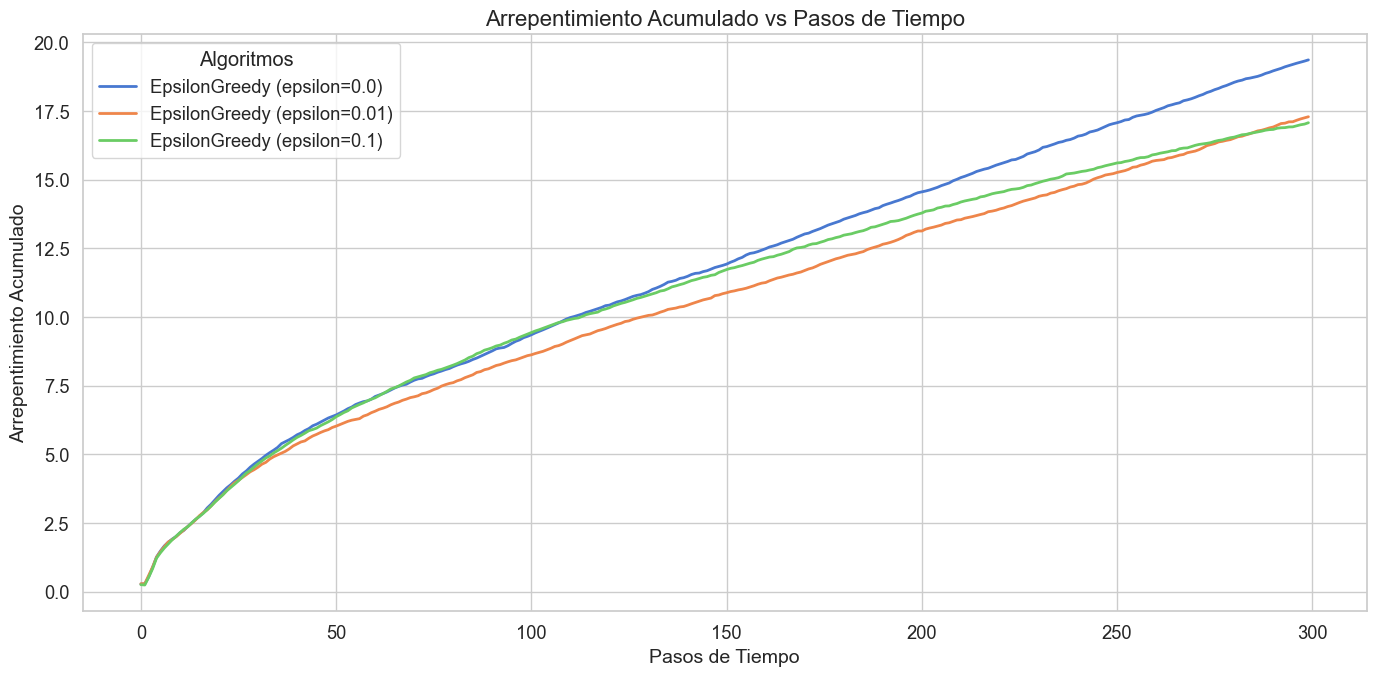

In [12]:
plot_regret(steps, cumulative_regret_per_algo_EBe, algorithms_epsilon)

#### Análisis Detallado de Selecciones Óptimas

La curva de selecciones óptimas en Bernoulli es un indicador crítico de la capacidad del algoritmo para discernir probabilidades. A la vista de esta gráfica observamos que a los algoritmos $\epsilon$-greedy les cuesta más aprender cuál es el brazo óptimo que en los otros dos bandidos. Se aprecia que hay un valle bastante pronunciado alrededor la iteración 20 y los algoritmos no empiezan a estabilizarse hasta la iteración 75, aproximadamente.

En cuanto al rendimiento de cada algoritmo, vemos que $\epsilon=0$ muestra una meseta totalmente plana, indicando que el agente se ha comprometido irrevocablemente con una acción que considera óptima, sea cierto o no. La curva de $\epsilon=0.01$ asciende a valores más elevados que la anterior y continúa ascendiendo lentamente, pero es inferior al algoritmo con $\epsilon=0.1$, que alcanza valores próximos al 90% en la última iteración.

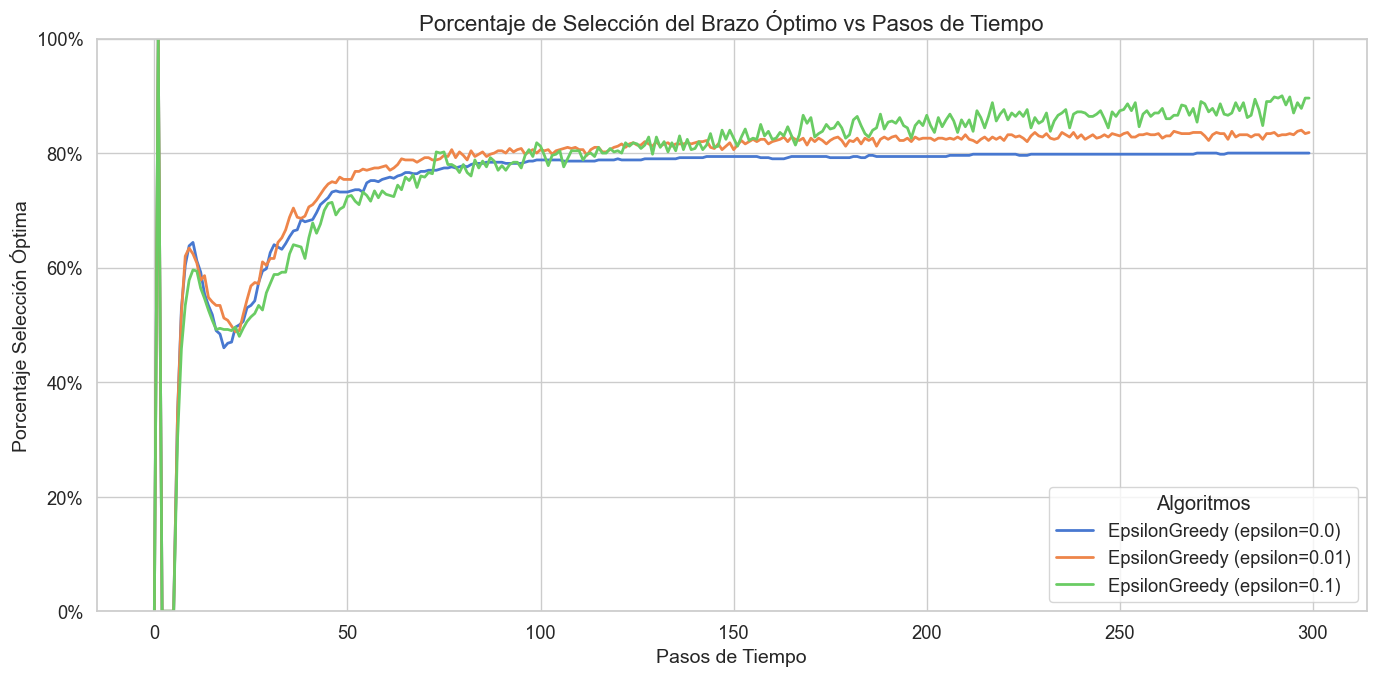

In [13]:
plot_optimal_selections(steps, optimal_selections_EBe, algorithms_epsilon)

#### Análisis Detallado de Estadísticas por Brazo

La distribución final de las jugadas confirma la identificación del brazo objetivo: a pesar de la naturaleza binaria y ruidosa de la recompensa, todos los algoritmos logran acumular la gran mayoría de las selecciones en el brazo con mayor $p$. Apreciamos que el peor de los brazos (el Brazo 4) es el que menos veces ha sido escogido por todos los algoritmos, pero aquel con $\epsilon=0.1$ es el que más lo ha elegido debido, precisamente, a tener una mayor probabilidad de escoger una acción aleatoria. También vemos que $\epsilon=0$ es el que menos veces ha elegido el brazo óptimo de entre los tres algortimos, posiblemente porque en ocasiones ha identificado erróneamente que el mejor brazo era brazo 5 o el 0, que son el segundo y tercer mejor brazo, respectivamente.

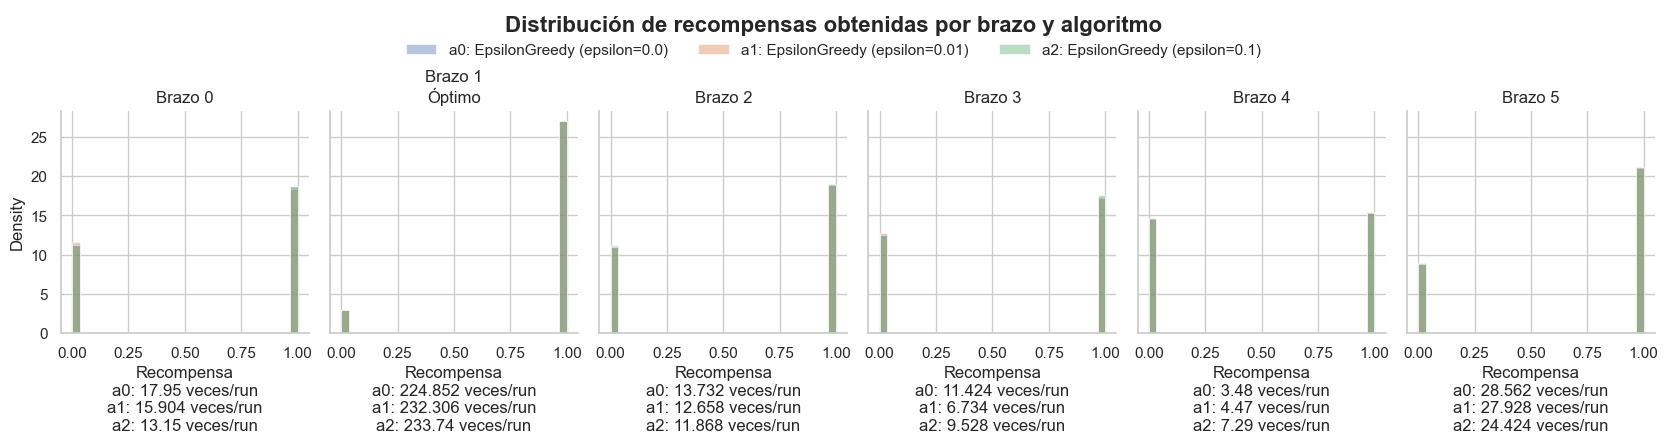

In [14]:
plot_arm_statistics(rewards_per_arm_per_algo_EBe, algorithms_epsilon, runs, optimal_arm_bernoulli, kde=False)

## Análisis de Epsilon-Decay

### Distribución Normal

### Distribución Binomial

### Distribución Bernoulli

## Conclusiones

A lo largo de este notebook, hemos explorado el rendimiento del algoritmo **Epsilon-Greedy** en el problema del bandido multibrazo, evaluando su comportamiento bajo tres distribuciones de recompensa distintas: Normal, Binomial y Bernoulli.

Los hallazgos principales se pueden resumir en los siguientes puntos:

1.  **El Dilema Exploración-Explotación**: Hemos comprobado empíricamente que existe un compromiso fundamental entre adquirir nueva información (exploración) y capitalizar el conocimiento actual (explotación).
    *   **$\epsilon=0$ (Greedy)**: Es una estrategia arriesgada. Aunque puede funcionar si las condiciones iniciales son favorables, a menudo converge prematuramente a óptimos locales, resultando en un desempeño subóptimo a largo plazo.
    *   **$\epsilon=0.1$ (Exploración Moderada)**: Aprende muy rápido al inicio, pero sufre de un "costo de exploración" asintótico. Nunca deja de explorar, lo que impide que la selección de la acción óptima supere el 90%.
    *   **$\epsilon=0.01$ (Baja Exploración)**: Representa el balance más robusto en los escenarios probados. Aunque su aprendizaje inicial es más lento que con $\epsilon=0.1$, a largo plazo logra mayores recompensas promedio y una tasa de selección óptima superior, ya que "desperdicia" menos turnos en opciones subóptimas una vez que ha identificado la mejor.

2.  **Robustez frente a Distribuciones**:
    *   El algoritmo demostró ser agnóstico a la distribución subyacente de las recompensas, manteniendo un ranking de rendimiento consistente ($\epsilon=0.01 > \epsilon=0.1 > \epsilon=0$) tanto para recompensas continuas (Normal) como discretas (Binomial, Bernoulli).
    *   Sin embargo, la varianza del proceso de aprendizaje sí se vio afectada. En distribuciones con mayor incertidumbre o ruido intrínseco, la estabilidad de las estimaciones tomó más tiempo en consolidarse.

3.  **Análisis de Regret**:
    *   Las curvas de regret acumulado confirmaron que cualquier estrategia con $\epsilon$ fijo incurre en un regret lineal a lo largo del tiempo. Para minimizar el regret asintótico a cero, sería necesario utilizar estrategias de **$\epsilon$-decay** (reducción progresiva de epsilon), lo cual sugiere una línea clara para trabajos futuros.

En resumen, Epsilon-Greedy es una estrategia base sólida y fácil de implementar, donde un valor pequeño de epsilon (como 0.01) suele ofrecer un rendimiento superior en entornos estáticos a largo plazo, superando tanto a la avidez pura como a la exploración excesiva.

## Referencias


<span id="apuntes">[1]</span> Hernández Molinero, L. D. (2025), *"Aprendizaje por Refuerzo. Bandido Multibrazo"*. Universidad de Murcia.

<span id="suttonbarto">[2]</span> Sutton, R., Barto, A. (2018), *"Reinforcement Learning, second edition: An Introduction"*. MIT Press.
